In [18]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate, correlation_lags
from scipy.ndimage import gaussian_gradient_magnitude
import napari


In [19]:
# -----------------------------
# Define paths using pathlib
# -----------------------------
input_data_folder = '2D TFM Data'
input_data_subfolder = 'Al Hole 3MHz 28012026'

# Current working directory
cwd = Path.cwd()
print("Current working directory:", cwd)

# Project root (one level up if your notebook is in STITCHING folder)
project_root = cwd.parent

# Full input directory path
IN_DIR = project_root / 'DATA' / input_data_folder / input_data_subfolder
print("Looking for files in:", IN_DIR)

# Check if folder exists
if not IN_DIR.exists():
    raise FileNotFoundError(f"The folder {IN_DIR} does not exist. Check your paths!")

# -----------------------------
# Find all .npy files
# -----------------------------
npy_files = [f for f in IN_DIR.iterdir() if f.suffix.lower() == ".npy" and f.is_file()]
npy_files = sorted(npy_files)  # optional, sort alphabetically

print("Files available in directory:")
for f in npy_files:
    print(f.name)
print()

# -----------------------------
# Load a specific file
# -----------------------------
vol1_path = IN_DIR / "Al_40_2_TFM_3D.npy"
vol1 = np.load(vol1_path)

vol2_path = IN_DIR / "Al_40_3_TFM_3D.npy"
vol2 = np.load(vol2_path)
print("Loaded image shapes:", vol1.shape, vol2.shape)

Current working directory: /Users/ottobruce-gardyne/Documents/Year4/GIP/signal-processing-G2066/STITCHING
Looking for files in: /Users/ottobruce-gardyne/Documents/Year4/GIP/signal-processing-G2066/DATA/2D TFM Data/Al Hole 3MHz 28012026
Files available in directory:
Al_40_1_TFM_3D.npy
Al_40_2_TFM_3D.npy
Al_40_3_TFM_3D.npy
Al_40_4_TFM_3D.npy
Al_40_5_TFM_3D.npy

Loaded image shapes: (300, 200, 200) (300, 200, 200)


Loading data...
Loaded Shapes -> Vol1: (300, 200, 200), Vol2: (300, 200, 200)
Calculating shift...
[MAX Projection] Optimal Shift: 91 px


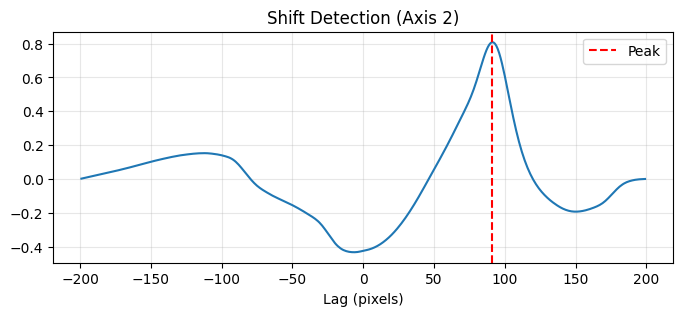

Stitching (Hard Cut Mode)...
Overlap: 109 px. Mode: cut
Final Stitched Shape: (300, 200, 291)
Opening Napari...


In [25]:
# ==========================================
# 1. CLASS DEFINITION
# ==========================================
class TFMStitcher:
    def __init__(self, vol1, vol2, axis=0):
        self.vol1 = vol1.astype(np.float32)
        self.vol2 = vol2.astype(np.float32)
        self.axis = axis
        self.shift_index = None
        self.correlation_curve = None
        self.lags = None

    def _project_to_1d(self, volume, method='max', roi=None):
        if roi is not None:
            slices = []
            for i, bounds in enumerate(roi):
                if bounds is None:
                    slices.append(slice(None))
                else:
                    slices.append(slice(bounds[0], bounds[1]))
            vol_subset = volume[tuple(slices)]
        else:
            vol_subset = volume

        collapse_axes = tuple([i for i in range(3) if i != self.axis])
        
        if method == 'max':
            projection = np.max(vol_subset, axis=collapse_axes)
        elif method == 'mean':
            projection = np.mean(vol_subset, axis=collapse_axes)
        elif method == 'edge':
            grads = gaussian_gradient_magnitude(vol_subset, sigma=2)
            projection = np.mean(grads, axis=collapse_axes)
        else:
            raise ValueError("Method must be 'max', 'mean', or 'edge'")

        if np.std(projection) == 0:
            return projection
            
        projection = (projection - np.mean(projection)) / (np.std(projection) + 1e-10)
        return projection

    def find_optimal_shift(self, proj_method='max', roi=None):
        sig1 = self._project_to_1d(self.vol1, proj_method, roi=roi)
        sig2 = self._project_to_1d(self.vol2, proj_method, roi=roi)
        
        corr = correlate(sig1, sig2, mode='full')
        lags = correlation_lags(len(sig1), len(sig2), mode='full')
        
        norm_factor = np.sqrt(np.sum(sig1**2) * np.sum(sig2**2))
        self.correlation_curve = corr / norm_factor
        self.lags = lags
        
        peak_idx = np.argmax(self.correlation_curve)
        self.shift_index = lags[peak_idx]
        
        print(f"[{proj_method.upper()} Projection] Optimal Shift: {self.shift_index} px")
        return self.shift_index

    def plot_correlation(self):
        plt.figure(figsize=(8, 3))
        plt.plot(self.lags, self.correlation_curve)
        plt.axvline(self.shift_index, color='r', linestyle='--', label='Peak')
        plt.title(f"Shift Detection (Axis {self.axis})")
        plt.xlabel("Lag (pixels)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    def stitch(self, blend_mode='linear'):
        if self.shift_index is None:
            raise RuntimeError("Run find_optimal_shift() first.")

        shift = int(round(self.shift_index))
        s1, s2 = self.vol1.shape, self.vol2.shape
        L1, L2 = s1[self.axis], s2[self.axis]

        # Calculate offsets
        offset_v1 = 0
        offset_v2 = shift
        if shift < 0:
            offset_v1 = abs(shift)
            offset_v2 = 0 
            
        end_v1 = offset_v1 + L1
        end_v2 = offset_v2 + L2
        total_len = max(end_v1, end_v2)
        
        out_shape = list(s1)
        out_shape[self.axis] = total_len
        stitched = np.zeros(out_shape, dtype=np.float32)

        def get_slice(start, length):
            sl = [slice(None)] * 3
            sl[self.axis] = slice(start, start + length)
            return tuple(sl)

        inter_start = max(offset_v1, offset_v2)
        inter_end = min(end_v1, end_v2)
        overlap_len = inter_end - inter_start

        if overlap_len <= 0:
            stitched[get_slice(offset_v1, L1)] = self.vol1
            stitched[get_slice(offset_v2, L2)] = self.vol2
        else:
            print(f"Overlap: {overlap_len} px. Mode: {blend_mode}")
            
            # A. Pre-Overlap
            len_pre = inter_start - offset_v1
            if len_pre > 0:
                stitched[get_slice(offset_v1, len_pre)] = self.vol1[get_slice(0, len_pre)]
            
            # B. Overlap
            idx1_start = inter_start - offset_v1
            idx2_start = inter_start - offset_v2
            chunk1 = self.vol1[get_slice(idx1_start, overlap_len)]
            chunk2 = self.vol2[get_slice(idx2_start, overlap_len)]

            if blend_mode == 'cut':
                mid = overlap_len // 2
                stitched[get_slice(inter_start, mid)] = chunk1[get_slice(0, mid)]
                remaining = overlap_len - mid
                stitched[get_slice(inter_start + mid, remaining)] = chunk2[get_slice(mid, remaining)]
            else:
                ramp = np.linspace(0, 1, overlap_len)
                ramp_shape = [1, 1, 1]
                ramp_shape[self.axis] = overlap_len
                w_entering = ramp.reshape(ramp_shape)
                w_exiting = 1.0 - w_entering
                
                if shift >= 0:
                    blended = (chunk1 * w_exiting) + (chunk2 * w_entering)
                else:
                    blended = (chunk2 * w_exiting) + (chunk1 * w_entering)
                stitched[get_slice(inter_start, overlap_len)] = blended

            # C. Post-Overlap
            len_post = end_v2 - inter_end
            if len_post > 0:
                src_start = idx2_start + overlap_len
                stitched[get_slice(inter_end, len_post)] = self.vol2[get_slice(src_start, len_post)]

        return stitched

# ==========================================
# 2. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    
    # --- A. LOAD REAL DATA ---
    input_data_folder = '2D TFM Data'
    input_data_subfolder = 'Al Hole 3MHz 28012026'
    cwd = Path.cwd()
    project_root = cwd.parent
    IN_DIR = project_root / 'DATA' / input_data_folder / input_data_subfolder
    
    vol1_path = IN_DIR / "Al_40_2_TFM_3D.npy"
    vol2_path = IN_DIR / "Al_40_3_TFM_3D.npy"
    
    if not vol1_path.exists():
        raise FileNotFoundError(f"Check path: {vol1_path}")

    # LOAD
    print("Loading data...")
    vol1 = np.load(vol1_path)
    vol2 = np.load(vol2_path)
    print(f"Loaded Shapes -> Vol1: {vol1.shape}, Vol2: {vol2.shape}")

    # --- B. CONFIGURE ---
    # 0 for Z (Scan Axis), 1 for Y (Depth), 2 for X (Width)
    # Check your data: is (300, 200, 200) -> (Scan, Depth, Width)? Then use 0.
    SCAN_AXIS = 2  
    
    # ROI for CORRELATION only (crops edges to find shift)
    # Adjust (20, -20) if your scan axis needs more/less cropping
    crop_roi = [
        (20, -20),  # Scan Axis
        None,       # Axis 1
        None        # Axis 2
    ]

    # --- C. RUN PIPELINE ---
    stitcher = TFMStitcher(vol1, vol2, axis=SCAN_AXIS)

    print("Calculating shift...")
    shift = stitcher.find_optimal_shift(proj_method='max', roi=crop_roi)
    
    stitcher.plot_correlation()
    
    print("Stitching (Hard Cut Mode)...")
    result = stitcher.stitch(blend_mode='cut')
    print(f"Final Stitched Shape: {result.shape}")

    # --- D. VISUALIZE ---
    try:
        print("Opening Napari...")
        viewer = napari.Viewer()
        
        # Calculate contrast limits so image isn't black or washed out
        clim = [np.min(vol1), np.max(vol1)]
        
        viewer.add_image(vol1, name='Vol1', colormap='cyan', blending='additive', contrast_limits=clim)
        
        trans = [0,0,0]
        trans[SCAN_AXIS] = shift
        viewer.add_image(vol2, name='Vol2', colormap='magenta', blending='additive', translate=trans, contrast_limits=clim)
        
        viewer.add_image(result, name='Result', colormap='magma', visible=False, contrast_limits=clim)
        
        napari.run()
    except Exception as e:
        print(f"Napari error: {e}")
    
    # --- E. SAVE RESULT ---
    # Define output folder name
    output_subfolder = "3D_stitching_results"
    OUT_DIR = cwd / output_subfolder
        
    # Create the folder if it doesn't exist
    OUT_DIR.mkdir(parents=True, exist_ok=True)
        
    # Define filename (e.g., combining input names)
    output_filename = "Al Hole 3MHz 28012026_Al_40_2_TFM_3D_and_Al_40_3_TFM_3D.npy"
    save_path = OUT_DIR / output_filename
    np.save(save_path, result)
     